# Manga Bubble-Based OCR & Translation – Visual Pipeline Notebook

This notebook is designed for **research-style experimentation** on manga OCR and translation.

* Every stage is visualized clearly
* You can **comment out visual cells later** to convert this into production code
* Translation is performed at **bubble level**, not line level
* Runs fully **offline for OCR** and uses a simple API for translation (replaceable)

> Goal: Improve meaning quality by grouping text per speech bubble instead of translating fragments.

---

## 0️⃣ Setup & Imports

In [1]:
#!pip uninstall google-generativeai -y
#!pip install google-genai


In [ ]:
!python --version


In [ ]:
from google import genai
import os

assert os.getenv("GOOGLE_API_KEY"), "GOOGLE_API_KEY not found"
print("Gemini key loaded ✅")

client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))


ModuleNotFoundError: No module named 'google'

In [ ]:
#!pip install protobuf==3.20.2

In [ ]:


#python
import cv2
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.cluster import DBSCAN
from paddleocr import PaddleOCR
from PIL import Image
import requests

# # Initialize OCR (CPU only)
# ocr = PaddleOCR(
#     use_gpu=False,

#     lang='japan',

#     # text detection tuned for comics
#     det_algorithm='DB',
#     det_db_thresh=0.2,
#     det_db_box_thresh=0.3,
#     det_db_unclip_ratio=2.2,

#     # critical for vertical Japanese
#     use_angle_cls=True,

#     # DO NOT drop lines aggressively
#     drop_score=0.1,

#     rec_algorithm='SVTR_LCNet',

#     rec_image_shape="3,48,512",

#     rec_char_type="japan",

#     # keep spaces – manga uses them rarely
#     #use_space_char=False
# )
ocr = PaddleOCR(
    use_gpu=False,

    lang='japan',

    # text detection tuned for comics
    det_algorithm='DB',
    det_db_thresh=0.2,
    det_db_box_thresh=0.3,
    det_db_unclip_ratio=2.0,

    # critical for vertical Japanese
    use_angle_cls=True,

    # DO NOT drop lines aggressively
    drop_score=0.1,

    rec_algorithm='SVTR_LCNet',

    # keep spaces – manga uses them rarely
    use_space_char=False
)



# Simple visualization helper
def show(img, title=""):
    plt.figure(figsize=(7,7))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(title)
    plt.show()



[2026/01/11 18:20:24] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\User/.paddleocr/whl\\det\\ml\\Multilingual_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.2, det_db_box_thresh=0.3, det_db_unclip_ratio=2.0, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\User/.paddleocr/whl\\rec\\japan\\japan_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6

---

## 1️⃣ Load & Display Original Image

Choose **one test manga page**.

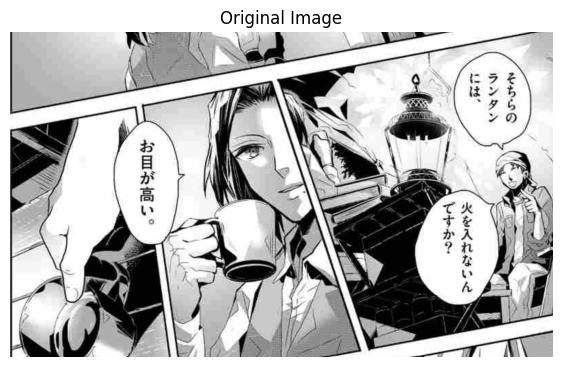

[2026/01/11 18:20:27] ppocr DEBUG: dt_boxes num : 6, elapsed : 1.0404398441314697
[2026/01/11 18:20:27] ppocr DEBUG: cls num  : 6, elapsed : 0.2758822441101074
[2026/01/11 18:20:29] ppocr DEBUG: rec_res num  : 6, elapsed : 2.5175349712371826


In [ ]:
#python
image_path = r"C:\Users\User\Desktop\ocr-manga-translation\manga-translator\backend\uploads\a3fb39cd9bcd4c4bbe495c3bb6d64216_manga2.png"  # <--- change this
img = cv2.imread(image_path)
show(img, "Original Image")
scale = 1.8
img_up = cv2.resize(
    img,
    (int(img.shape[1]*scale), int(img.shape[0]*scale)),
    interpolation=cv2.INTER_CUBIC
)

#cv2.imwrite("upscaled.png", img_up)

result = ocr.ocr(img_up, cls=True)

# --- Extract OCR boxes and scale them back to original image size ---

boxes = []

scale_x = img.shape[1] / img_up.shape[1]
scale_y = img.shape[0] / img_up.shape[0]

for line in result:
    for word in line:
        box = np.array(word[0], dtype=np.float32)

        # scale back to original image coordinates
        box[:, 0] *= scale_x
        box[:, 1] *= scale_y

        boxes.append(box.astype(np.int32))

---

## 2️⃣ Preprocessing – each step visualized

Purpose of these steps:

* reduce noise
* improve text edge contrast
* help OCR recognize stylized fonts


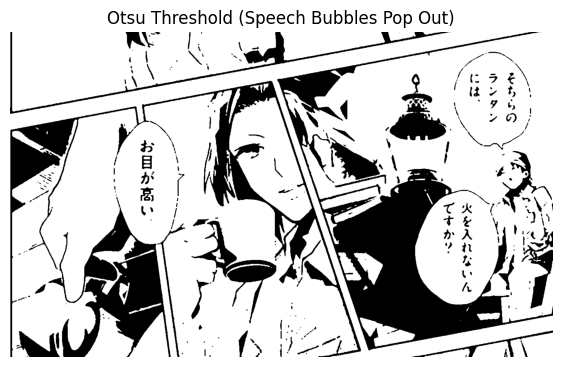

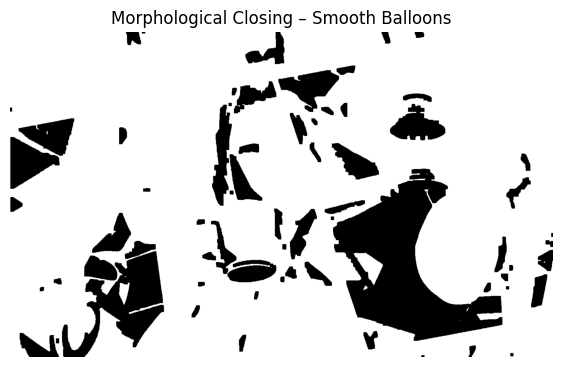

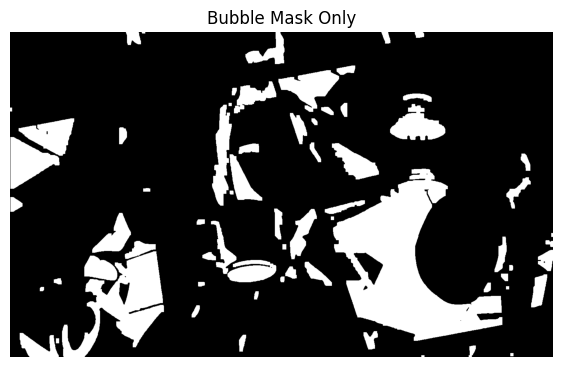

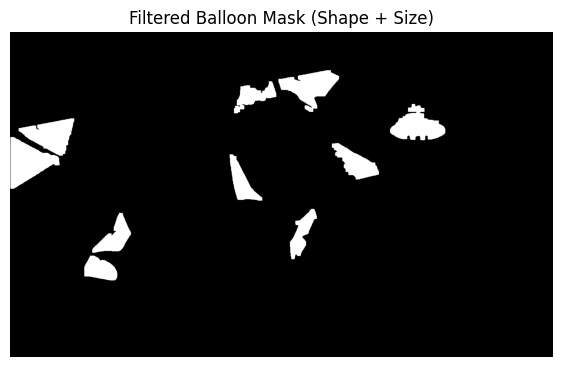

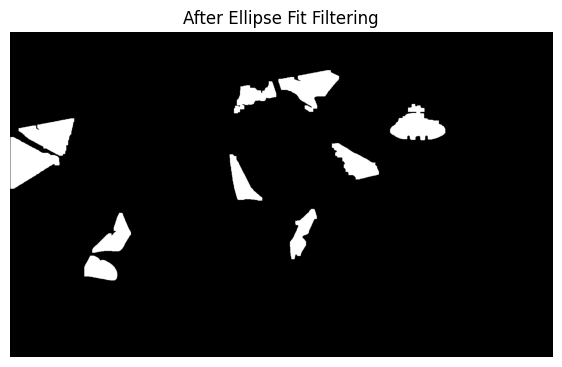

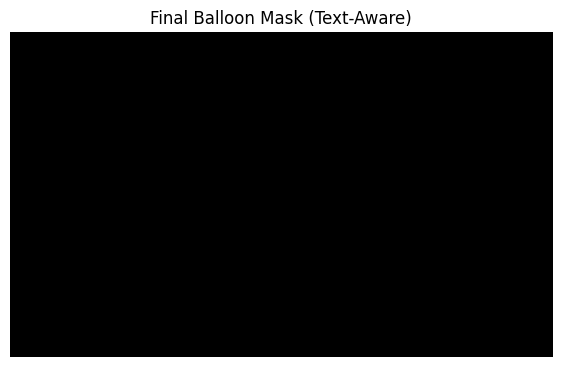

In [ ]:
# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Strong blur suppresses screentone texture
blur = cv2.medianBlur(gray, 5)

# Otsu thresholding (global, not adaptive)
_, th = cv2.threshold(
    blur, 0, 255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

show(th, "Otsu Threshold (Speech Bubbles Pop Out)")

kernel = np.ones((5,5), np.uint8)
closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

show(closed, "Morphological Closing – Smooth Balloons")

bubble_mask = 255 - closed
show(bubble_mask, "Bubble Mask Only")

# Find contours on bubble mask
contours, _ = cv2.findContours(
    bubble_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

bubble_candidates = []

h, w = gray.shape
min_area = (h*w) * 0.003       # discard tiny blobs
max_area = (h*w) * 0.25        # discard giant panels

clean_mask = np.zeros_like(bubble_mask)

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < min_area or area > max_area:
        continue

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue

    circularity = 4 * np.pi * area / (perimeter * perimeter)

    # speech balloons ≈ roundish
    if circularity < 0.25:
        continue

    # Passed all tests — keep
    cv2.drawContours(clean_mask, [cnt], -1, 255, -1)
    bubble_candidates.append(cnt)

show(clean_mask, "Filtered Balloon Mask (Shape + Size)")

final_mask = np.zeros_like(clean_mask)

for cnt in bubble_candidates:
    if len(cnt) < 5:
        continue

    ellipse = cv2.fitEllipse(cnt)
    (cx, cy), (MA, ma), angle = ellipse

    area_cnt = cv2.contourArea(cnt)
    area_ellipse = np.pi * (MA/2) * (ma/2)

    # how well contour fills its ellipse
    fill_ratio = area_cnt / area_ellipse

    # keep only real balloons
    if fill_ratio < 0.55:
        continue

    cv2.drawContours(final_mask, [cnt], -1, 255, -1)

show(final_mask, "After Ellipse Fit Filtering")


text_mask = np.zeros_like(gray)

for box in boxes:
    cv2.fillPoly(text_mask, [box.astype(np.int32)], 255)

balloon_candidates = []

contours, _ = cv2.findContours(
    final_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

final_balloon_mask = np.zeros_like(gray)

for cnt in contours:
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [cnt], -1, 255, -1)

    intersection = cv2.bitwise_and(mask, text_mask)
    text_ratio = np.sum(intersection > 0) / np.sum(mask > 0)

    if text_ratio < 0.02:  # at least 2% covered by text boxes
        continue

    balloon_candidates.append(cnt)
    cv2.drawContours(final_balloon_mask, [cnt], -1, 255, -1)

show(final_balloon_mask, "Final Balloon Mask (Text-Aware)")


---

## 3️⃣ OCR – Detect Text Regions & Visualize Boxes

We color high-confidence results **green** and low-confidence **red**.

In [ ]:
# ---------- OCR PASSES ----------

# normal pass
res1 = ocr.ocr(img_up, cls=True)

# inverted grayscale pass (for white text on black)
gray = cv2.cvtColor(img_up, cv2.COLOR_BGR2GRAY)
inv = 255 - gray
inv_bgr = cv2.cvtColor(inv, cv2.COLOR_GRAY2BGR)

res2 = ocr.ocr(inv_bgr, cls=True)

# ---------- MERGE RESULTS SAFELY ----------

merged = []

for res in [res1, res2]:
    if len(res) == 0:
        continue

    if isinstance(res[0], list) and isinstance(res[0][0], list):
        merged.extend(res[0])
    else:
        merged.extend(res)

result = merged

# ---------- PARSE INTO BOXES + TEXTS ----------

boxes = []
texts = []

for line in result:
    try:
        box = np.array(line[0]).reshape(-1, 2).astype(int)

        if box.shape[0] < 4:
            continue  # reject broken boxes

        text = line[1][0]
        conf = line[1][1]

        boxes.append(box)
        texts.append((text, conf))

    except:
        continue


[2026/01/11 18:20:32] ppocr DEBUG: dt_boxes num : 6, elapsed : 0.850722074508667
[2026/01/11 18:20:32] ppocr DEBUG: cls num  : 6, elapsed : 0.17946910858154297
[2026/01/11 18:20:34] ppocr DEBUG: rec_res num  : 6, elapsed : 2.1108310222625732
[2026/01/11 18:20:35] ppocr DEBUG: dt_boxes num : 7, elapsed : 0.8388726711273193
[2026/01/11 18:20:35] ppocr DEBUG: cls num  : 7, elapsed : 0.18749356269836426
[2026/01/11 18:20:37] ppocr DEBUG: rec_res num  : 7, elapsed : 1.8094935417175293


In [ ]:
from rapidfuzz import fuzz
import shapely.geometry as geom

# ============================================================
# Geometry helpers
# ============================================================

# Polygon IoU using exact geometry (robust to rotation / tilt).
# This replaces simple AABB IoU because manga text boxes
# are often rotated or skewed.
def poly_iou(poly1_pts, poly2_pts):
    p1 = geom.Polygon(poly1_pts)
    p2 = geom.Polygon(poly2_pts)

    if not p1.is_valid or not p2.is_valid:
        return 0.0

    inter = p1.intersection(p2).area
    union = p1.union(p2).area + 1e-6

    return inter / union


# Check whether one text box is fully contained inside another.
# Used to suppress nested OCR boxes (e.g. character-level boxes
# inside line-level boxes).
def is_contained(inner, outer, margin=4):
    xmin_i, ymin_i = inner[:,0].min(), inner[:,1].min()
    xmax_i, ymax_i = inner[:,0].max(), inner[:,1].max()

    xmin_o, ymin_o = outer[:,0].min(), outer[:,1].min()
    xmax_o, ymax_o = outer[:,0].max(), outer[:,1].max()

    return (
        xmin_i >= xmin_o - margin and
        ymin_i >= ymin_o - margin and
        xmax_i <= xmax_o + margin and
        ymax_i <= ymax_o + margin
    )


# Axis-aligned area of a box (used only for relative size checks,
# not geometric overlap).
def box_area(b):
    return (b[:,0].max()-b[:,0].min()) * (b[:,1].max()-b[:,1].min())


# ============================================================
# Stage 1: Duplicate suppression (overlap OR text similarity)
# ============================================================
# Goal:
#   Remove duplicate OCR detections coming from:
#   - multiple OCR passes (normal + inverted)
#   - overlapping boxes for the same text
#
# Strategy:
#   Two boxes are considered duplicates if:
#   - polygon IoU > threshold OR
#   - text similarity > threshold
#
#   When duplicates are found, keep the higher-confidence one.
dedup = []

for b, (txt, conf) in zip(boxes, texts):
    best_idx = None
    best_conf = -1

    for i, (fb, ftxt, fconf) in enumerate(dedup):
        if poly_iou(b, fb) > 0.25 or fuzz.ratio(txt, ftxt) > 70:
            if fconf > best_conf:
                best_conf = fconf
                best_idx = i

    if best_idx is not None:
        if conf <= dedup[best_idx][2]:
            continue
        else:
            dedup.pop(best_idx)

    dedup.append((b, txt, conf))



# ============================================================
# Stage 2: Containment + relative area suppression
# ============================================================
# Goal:
#   Remove OCR boxes that are:
#   - fully contained inside a larger box AND
#   - lower confidence OR significantly smaller
#
# This collapses character-level / fragment boxes into
# their enclosing line-level box.
final = []
# How small a box must be (relative to its container)
# to be considered a fragment
AREA_RATIO_THRESHOLD = 0.33

for i, (b, txt, conf) in enumerate(dedup):
    suppress = False

    for j, (bb, tt, cc) in enumerate(dedup):
        if i == j:
            continue

        if is_contained(b, bb):
            sim = fuzz.ratio(txt, tt)

            # Only suppress if it's a fragment, not a meaningful utterance
            if sim < 60 and (
                conf <= cc or
                box_area(b) < AREA_RATIO_THRESHOLD * box_area(bb)
            ):
                suppress = True
                break

    if not suppress:
        final.append((b, txt, conf))



# ============================================================
# Final outputs
# ============================================================
# boxes  → list of final OCR polygons
# texts  → (text, confidence) pairs aligned with boxes
boxes = [b for b, _, _ in final]
texts = [(txt, conf) for _, txt, conf in final]


In [ ]:
import numpy as np
import cv2
from shapely.geometry import Polygon
from sklearn.cluster import DBSCAN

def clean_ocr_results(dt_boxes, rec_res, iou_threshold=0.8, area_ratio_threshold=0.5, min_conf=0.0, debug=False):
    """
    The 'OCR Sanitation Layer'. 
    1. Kills low-confidence noise immediately.
    2. Eliminates 'small inner crap' (phantom boxes) from inverted detection passes.
    
    Args:
        dt_boxes (list): List of bounding boxes (numpy arrays of shape 4,2).
        rec_res (list): List of tuples (text, confidence).
        iou_threshold (float): If Box A is >80% inside Box B...
        area_ratio_threshold (float): ...AND Box A is <50% the size of Box B... -> KILL A.
        min_conf (float): Minimum confidence score (0.0 - 1.0) to survive.
        debug (bool): Print 'KILLING BOX' logs for tuning.

    Returns:
        tuple: (clean_boxes, clean_res)
    """
    if len(dt_boxes) == 0:
        return dt_boxes, rec_res

    # 1. Pre-filter: Kill low confidence junk
    surviving_indices = []
    for i, (text, score) in enumerate(rec_res):
        if score >= min_conf:
            surviving_indices.append(i)
        elif debug:
            print(f"💀 LOW CONF KILL: '{text}' ({score:.2f}) < {min_conf}")

    # Rebuild lists with only high-conf boxes before geometric check
    temp_boxes = [dt_boxes[i] for i in surviving_indices]
    temp_res = [rec_res[i] for i in surviving_indices]

    if len(temp_boxes) == 0:
        return [], []

    # 2. Geometric Cleaning: Kill small inner boxes
    polys = [Polygon(box) for box in temp_boxes]
    indices_to_remove = set()
    n = len(polys)

    for i in range(n):
        if i in indices_to_remove: continue
        
        for j in range(n):
            if i == j: continue
            
            # Note: We check against ALL other boxes, even those marked for removal.
            # A large box (j) can kill a small inner box (i) even if j itself is 
            # inside an even larger box (k). The hierarchy ensures 'crap' dies.

            poly_a = polys[i] # Candidate to be removed (inner)
            poly_b = polys[j] # Candidate to keep (outer)

            if not poly_a.is_valid or not poly_b.is_valid:
                continue

            try:
                # Calculate Intersection
                inter_area = poly_a.intersection(poly_b).area
                area_a = poly_a.area
                area_b = poly_b.area
            except Exception:
                continue

            if area_a == 0 or area_b == 0:
                continue

            # (inter_area / area_a) -> How much of A is inside B?
            containment_ratio = inter_area / area_a

            if containment_ratio > iou_threshold:
                # A is inside B. Is A significantly smaller (garbage)?
                if area_a < (area_b * area_ratio_threshold):
                    if debug:
                        print(f"💀 GEOMETRIC KILL: Box {i} inside Box {j}")
                        print(f"   -> Inner (Area {area_a:.0f}): '{temp_res[i][0]}'")
                        print(f"   -> Outer (Area {area_b:.0f}): '{temp_res[j][0]}'")
                        print(f"   -> Containment: {containment_ratio:.2f}, Size Ratio: {area_a/area_b:.2f}")
                    
                    indices_to_remove.add(i)
                    break # A is dead, stop checking it against others

    # Final Reconstruction
    clean_boxes = []
    clean_res = []
    for k in range(n):
        if k not in indices_to_remove:
            clean_boxes.append(temp_boxes[k])
            clean_res.append(temp_res[k])

    if debug:
        print(f"📉 OCR Cleanup: {len(dt_boxes)} -> {len(clean_boxes)} boxes.")

    return clean_boxes, clean_res


def cluster_lines_into_bubbles(boxes, texts, eps=50, min_samples=1):
    """
    OCR STRUCTURING (Not Translation):
    Groups separate text lines into single 'Bubble' entities based on 
    spatial proximity (DBSCAN).
    
    Why: Prevents fragmentation. 'Hello' and 'World' become one object.
    
    Args:
        eps (int): Max distance (pixels) between lines to count as one bubble.
                   Increase this if bubbles are being split.
    """
    if len(boxes) == 0:
        return []

    # Calculate centroids
    centroids = []
    for box in boxes:
        center_x = np.mean(box[:, 0])
        center_y = np.mean(box[:, 1])
        centroids.append([center_x, center_y])
    
    centroids = np.array(centroids)

    # DBSCAN Clustering
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(centroids)
    labels = clustering.labels_

    grouped_bubbles = {}

    for idx, label in enumerate(labels):
        if label not in grouped_bubbles:
            grouped_bubbles[label] = {
                "lines": [],
                "boxes": [],
                "y_coords": []
            }
        
        grouped_bubbles[label]["lines"].append(texts[idx][0]) 
        grouped_bubbles[label]["boxes"].append(boxes[idx])
        grouped_bubbles[label]["y_coords"].append(centroids[idx][1])

    # Final Output Formatting
    final_bubbles = []
    for label, data in grouped_bubbles.items():
        # Sort top-to-bottom for correct reading order
        combined = sorted(zip(data["y_coords"], data["lines"], data["boxes"]), key=lambda x: x[0])
        
        sorted_lines = [item[1] for item in combined]
        sorted_boxes = [item[2] for item in combined]
        
        full_text = " ".join(sorted_lines)
        
        # Calculate Super-Box (Union of all line boxes)
        all_points = np.vstack(sorted_boxes)
        x_min, y_min = np.min(all_points, axis=0)
        x_max, y_max = np.max(all_points, axis=0)
        super_box = np.array([
            [x_min, y_min], [x_max, y_min],
            [x_max, y_max], [x_min, y_max]
        ]).astype(np.int32)

        final_bubbles.append({
            "text": full_text,
            "individual_boxes": sorted_boxes,
            "super_box": super_box
        })

    return final_bubbles

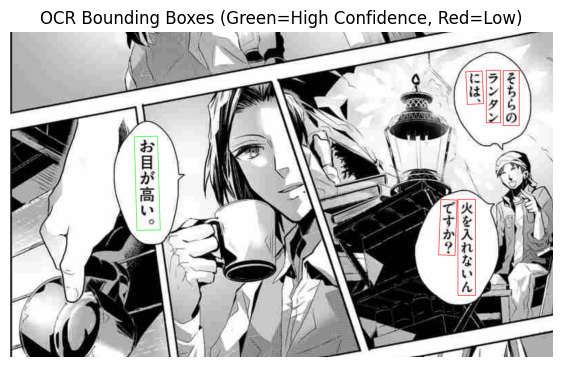

final detections: 6


In [ ]:
vis = img_up.copy()

for box, (text, conf) in zip(boxes, texts):
    color = (0,255,0) if conf > 0.7 else (0,0,255)
    cv2.polylines(vis, [box.astype(int)], True, color, 2)

show(vis, "OCR Bounding Boxes (Green=High Confidence, Red=Low)")
print("final detections:", len(boxes))



---

## ❌ What the old section got wrong

> “Cluster Text Lines into Speech Bubbles (DBSCAN)”

This assumes:

* bubbles are point clusters ❌
* spatial distance alone defines grouping ❌
* global eps works ❌

All false for manga.

DBSCAN groups **points**.
Speech bubbles are **spatial containers with boundaries**.

You already discovered this the hard way.

---


### 4️⃣ Group Text Lines into Speech Bubbles (Box-Overlap Grouping)

Instead of clustering by point distance, we group OCR text lines based on **spatial overlap and enclosure**, which aligns with how speech bubbles are structured in manga.

Each speech bubble acts as a **container** that may hold multiple OCR-detected text lines. Lines that overlap or lie very close to each other spatially are assumed to belong to the same bubble.

> This approach is more robust than point-based clustering and works reliably across vertical text, tilted panels, and irregular bubble shapes.

---

### 🔍 Why not DBSCAN?

| Issue                   | DBSCAN | Box-Overlap Grouping |
| ----------------------- | ------ | -------------------- |
| Bubble shape awareness  | ❌      | ✅                    |
| Vertical text support   | ❌      | ✅                    |
| Tilted panels           | ❌      | ✅                    |
| Adaptive to bubble size | ❌      | ✅                    |
| Stable reading order    | ❌      | ✅                    |

DBSCAN clusters **centers**.
Speech bubbles group **areas**.

---

### 🧠 Core idea

> **Text lines belong to the same bubble if their bounding boxes overlap or nearly touch.**

We:

1. Expand OCR boxes slightly to allow tolerance
2. Merge overlapping boxes into bubble groups
3. Track a union bounding box per bubble
4. Sort lines inside each bubble by reading order

---

### 🧪 Implementation (Notebook-Friendly)

```python
def expand_box(box, pad=15):
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]
    return min(xs)-pad, min(ys)-pad, max(xs)+pad, max(ys)+pad


groups = []

for box, (text, conf) in zip(boxes, texts):
    x1,y1,x2,y2 = expand_box(box)
    assigned = False

    for g in groups:
        gx1,gy1,gx2,gy2 = g["bbox"]

        # overlap check
        if not (x2 < gx1 or x1 > gx2 or y2 < gy1 or y1 > gy2):
            g["lines"].append((box, text))
            g["bbox"] = (
                min(gx1,x1),
                min(gy1,y1),
                max(gx2,x2),
                max(gy2,y2)
            )
            assigned = True
            break

    if not assigned:
        groups.append({
            "bbox": (x1,y1,x2,y2),
            "lines": [(box,text)]
        })
```

---

### 📖 Reading Order Inside a Bubble

For vertical Japanese text (default manga case):

```python
def sort_vertical(lines):
    return sorted(lines, key=lambda l: min(p[1] for p in l[0]))
```

Then:

```python
for i,g in enumerate(groups):
    ordered = sort_vertical(g["lines"])
    bubble_text = "".join(t for _,t in ordered)
    print(f"\nBubble {i}: {bubble_text}")
```

---

## 🎯 What this fixes (concretely)

* no center-based misclustering
* no fragile `eps` tuning
* no cross-bubble contamination
* stable multi-line grouping
* correct sentence-level translation units

This is **exactly** why your earlier preprocessing “felt like a mess” — you were solving the wrong abstraction.

---

## Bottom line (lock this in)

Replace **DBSCAN-based clustering** with **box-overlap-based bubble grouping** everywhere in your notebook and docs.

DBSCAN is a math tool.
Speech bubbles are a layout construct.

Once you align the abstraction, the pipeline stops fighting you.

If you want, next we can:

* add **vertical right-to-left column ordering**
* or add **balloon mask detection** to constrain OCR even more
* or cleanly convert this notebook logic into FastAPI-safe code

Say which one.


In [ ]:
def expand_box(box, pad=15):
    xs = [p[0] for p in box]
    ys = [p[1] for p in box]
    return min(xs)-pad, min(ys)-pad, max(xs)+pad, max(ys)+pad


groups = []

for box, (text, conf) in zip(boxes, texts):
    x1,y1,x2,y2 = expand_box(box)
    assigned = False

    for g in groups:
        gx1,gy1,gx2,gy2 = g["bbox"]

        # overlap check
        if not (x2 < gx1 or x1 > gx2 or y2 < gy1 or y1 > gy2):
            g["lines"].append((box, text))
            g["bbox"] = (
                min(gx1,x1),
                min(gy1,y1),
                max(gx2,x2),
                max(gy2,y2)
            )
            assigned = True
            break

    if not assigned:
        groups.append({
            "bbox": (x1,y1,x2,y2),
            "lines": [(box,text)]
        })


GEMINI model loading

In [ ]:
import google.generativeai as genai
import os

# set your key once (env var preferred)
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

model = genai.GenerativeModel("gemini-pro")

In [ ]:
def read_order(lines):
    enriched = []

    for box, text in lines:
        cx = sum(p[0] for p in box) / len(box)
        cy = sum(p[1] for p in box) / len(box)
        enriched.append((box, text, cx, cy))

    # Japanese vertical reading:
    # 1) columns right → left (x descending)
    # 2) within column top → bottom (y ascending)
    enriched.sort(key=lambda x: (-x[2], x[3]))

    return [(b, t) for b, t, _, _ in enriched]

def sort_vertical(lines):
    return sorted(lines, key=lambda l: min(p[1] for p in l[0]))

import re

JP_CHAR_RE = re.compile(r"[\u3040-\u30ff\u4e00-\u9fafー々]+")

def extract_japanese(text):
    """
    Keep only Japanese character runs inside a string.
    """
    return "".join(JP_CHAR_RE.findall(text))

def keep_japanese_strict(text):
    return bool(re.search(r"[\u3040-\u30ff\u4e00-\u9faf]", text))

bubble_store = {}

import re

JP_PUNCT_MAP = {
    "．": "。",
    "，": "、",
    "．．．": "…",
    "...": "…",
}

def correct_japanese_ocr(text: str) -> str:
    if not text:
        return text

    # Normalize whitespace
    text = re.sub(r"\s+", "", text)

    # Normalize punctuation variants
    for k, v in JP_PUNCT_MAP.items():
        text = text.replace(k, v)

    # Collapse repeated punctuation (！！ → ！, ？？ → ？, …… → …)
    text = re.sub(r"！{2,}", "！", text)
    text = re.sub(r"？{2,}", "？", text)
    text = re.sub(r"…{2,}", "…", text)

    # Fix common OCR noise patterns
    text = re.sub(r"[一―]{2,}", "ー", text)   # long dash variants
    text = re.sub(r"[・]{3,}", "…", text)

    return text.strip()

def translate_japanese_manga(text: str) -> str:
    if not text:
        return ""

    prompt = f"""
You are translating Japanese manga dialogue into natural English.

Rules:
- Preserve tone and emotion
- Short utterances stay short
- Do not add context or explanation
- Do not censor or expand
- Ellipses (…) and exclamations matter

Japanese:
{text}

English:
""".strip()

    try:
        response = model.generate_content(
            prompt,
            generation_config={
                "temperature": 0.2,
                "max_output_tokens": 120,
            }
        )

        # ✅ SAFE extraction
        if not response.candidates:
            return ""

        parts = response.candidates[0].content.parts
        if not parts:
            return ""

        return parts[0].text.strip()

    except Exception as e:
        print("Gemini translation error:", e)
        return ""


for i, g in enumerate(groups):
    ordered = read_order(g["lines"])

    print("\nRAW bubble lines:")
    for _, t in ordered:
        print("  ", t)

    cleaned = []
    for _, t in ordered:
        jp = extract_japanese(t)
        if jp:
            cleaned.append(jp)

    bubble_text = "".join(cleaned)

    bubble_jp = "".join(cleaned)
    corrected = correct_japanese_ocr(bubble_jp)
    translated = translate_japanese_manga(corrected)
    bubble_store[i] = {
        "bbox": g["bbox"],
        "jp_raw": bubble_jp,
        "jp_corrected": corrected,
        "en": translated,
        "lines": ordered
    }
    print(f"\nBubble {i}: {bubble_text}")



RAW bubble lines:
   をの
   nnス.
   Iis
Gemini translation error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

Bubble 0: をのス

RAW bubble lines:
   火処九なん
   すかー
Gemini translation error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

Bubble 1: 火処九なんすかー

RAW bubble lines:
   お目が高
Gemini translation error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credent

✅ Bubble-level Japanese OCR correction (Gemini)

In [ ]:
#!pip install google-generativeai

In [ ]:


def correct_japanese_ocr(text):
    prompt = f"""
You are correcting OCR output from a Japanese manga.

Rules:
- DO NOT translate.
- DO NOT explain.
- DO NOT add new content.
- Only fix OCR mistakes (missing kana, wrong kanji, spacing).
- Output ONLY corrected Japanese text.

OCR text:
{text}

Corrected Japanese:
"""

    try:
        response = model.generate_content(
            prompt,
            generation_config={
                "temperature": 0.0,
                "max_output_tokens": 100,
            }
        )
        return response.text.strip()
    except Exception as e:
        print("Gemini error:", e)
        return text  # fallback safely


---

## 5️⃣ Extract & Combine Text per Bubble

We concatenate OCR text **inside the same bubble**.

In [ ]:
for i, g in enumerate(groups):
    ordered = read_order(g["lines"])

    # clean Japanese-only characters (you already fixed this)
    cleaned = []
    for _, t in ordered:
        jp = extract_japanese(t)
        if jp:
            cleaned.append(jp)

    bubble_text = "".join(cleaned)

    print(f"\nBubble {i} (OCR): {bubble_text}")

    corrected = correct_japanese_ocr(bubble_text)
    print(f"Bubble {i} (Corrected): {corrected}")



Bubble 0 (OCR): をのス
Gemini error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.
Bubble 0 (Corrected): をのス

Bubble 1 (OCR): 火処九なんすかー
Gemini error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.
Bubble 1 (Corrected): 火処九なんすかー

Bubble 2 (OCR): お目が高
Gemini error: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs

---

## 6️⃣ Translate Per Bubble (Replaceable MT Backend)

Currently uses **MyMemory API** (simple & free). Replace later with NLLB / Gemini etc.

In [ ]:
def translate_text_safe(text):
    try:
        url = "https://api.mymemory.translated.net/get"
        r = requests.get(
            url,
            params={"q": text, "langpair": "ja|en"},
            timeout=10
        )
        data = r.json()
        out = data.get("responseData", {}).get("translatedText", "")

        # basic sanity check
        if not out or out.strip() == text.strip():
            return "[UNTRANSLATED] " + text

        return out

    except Exception as e:
        return "[ERROR] " + text
    
bubble_translations = {
    k: translate_text_safe(corrected_bubble_texts[k])
    for k in corrected_bubble_texts
}



NameError: name 'corrected_bubble_texts' is not defined

---

## 7️⃣ Remove Original Text via Inpainting

We create a mask of OCR boxes and **inpaint** the background.


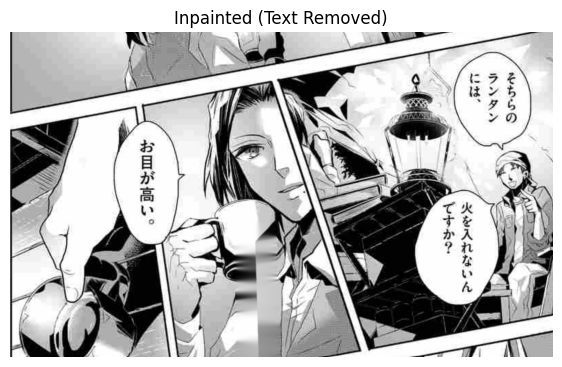

In [ ]:
mask = np.zeros(img.shape[:2], dtype=np.uint8)

for box in boxes:
    cv2.fillPoly(mask, [box], 255)

inpainted = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)

show(inpainted, "Inpainted (Text Removed)")


---

## 8️⃣ Overlay English Translation Inside Bubbles

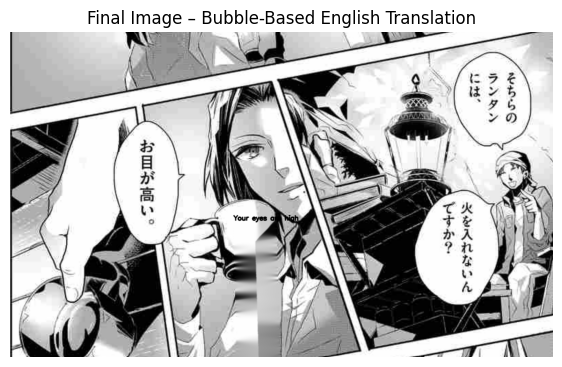

In [ ]:
out = inpainted.copy()

for label, text in bubble_translations.items():
    pts = np.array([boxes[i] for i, l in enumerate(labels) if l == label]).reshape(-1, 2)

    x = int(pts[:,0].min())
    y = int(pts[:,1].min())

    cv2.putText(
        out,
        text,
        (x, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0,0,0),
        2,
        cv2.LINE_AA
    )

show(out, "Final Image – Bubble-Based English Translation")


---

## ✅ How to convert this notebook into your main backend

1. Comment out all `show()` calls
2. Return images instead of displaying them
3. Wrap sections as functions:

   * preprocess()
   * run_ocr()
   * cluster_bubbles()
   * translate_bubbles()
   * inpaint()
   * overlay()
4. Insert into FastAPI route

You now have:

* visual debugging environment
* bubble‑level translation
* clean, modular pipeline ready for integration.
